In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset_name = 'Uniform'
path = './spectrum/Teacher_Generated/{"bsel":"' + dataset_name + '","seed":1,"model":"TwoLayer","opt":"adamw","bs":320,"ratio":0.1,"lr":0.001,"wd":0.01}.p'
payload = torch.load(path)

In [15]:
evals = np.array(payload['eigenvalues'])[:,1:100]
steps = payload['steps']

In [16]:
num_checkpoints, num_evals = evals.shape

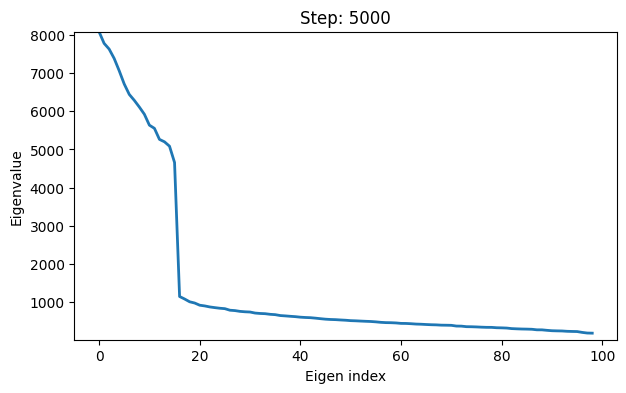

In [17]:
from matplotlib import animation
from IPython.display import HTML

# evals has shape (num_checkpoints, num_evals) and is already sorted per-eigenvalue
# steps is a list/array of step indices corresponding to checkpoints

num_checkpoints, num_evals = evals.shape
x = np.arange(num_evals)

fig, ax = plt.subplots(figsize=(7,4))
line, = ax.plot(x, evals[0], lw=2)
ax.set_xlabel('Eigen index')
ax.set_ylabel('Eigenvalue')
ax.set_title(f'Step: {steps[0]}')
# use log scale if eigenvalues span many orders
# ax.set_yscale('log')
ax.set_ylim(evals.min(), evals.max())

def update(i):
    line.set_ydata(evals[i])
    ax.set_title(f'Step: {steps[i]}')
    return (line,)

ani = animation.FuncAnimation(fig, update, frames=num_checkpoints, interval=250, blit=True)

# Render as an embedded JS animation in the notebook
HTML(ani.to_jshtml())

In [18]:
print(evals.max())

8088.1455
